$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 4.13

小型极大极小设计（样本量与维度比值 $n_1/p$ 较小）不利于相关参数的估计，该现象是极大极小设计投影效果较差所造成的固有问题。图 4.13 展示了六维、64 次试验的极大极小设计样本点两两间距的直方图。由于 $64<2^6$，所有样本点都会被挤压至超立方体 $[0, 1]^6$ 的各个顶点处，最终仅存在少量互不相同的两两间距。该图同时给出了 64 次试验的最大投影（MaxPro）设计对应的样本两两间距分布。可以观察到最大投影设计的样本间距几乎呈连续分布，能够利用形状参数为 10.1 与 12.7 的缩放贝塔分布实现良好拟合，贝塔分布的形状参数由样本量 $n$ 与维度 $p$ 确定。尽管最大投影设计的设计初衷是保障预测效果，但该类设计的样本两两间距恰好天然具备贝塔分布特性，因此可以推断，最大投影设计在相关参数估计方面同样能取得优良效果。

shape1: 10.0895 
shape2: 12.72548 


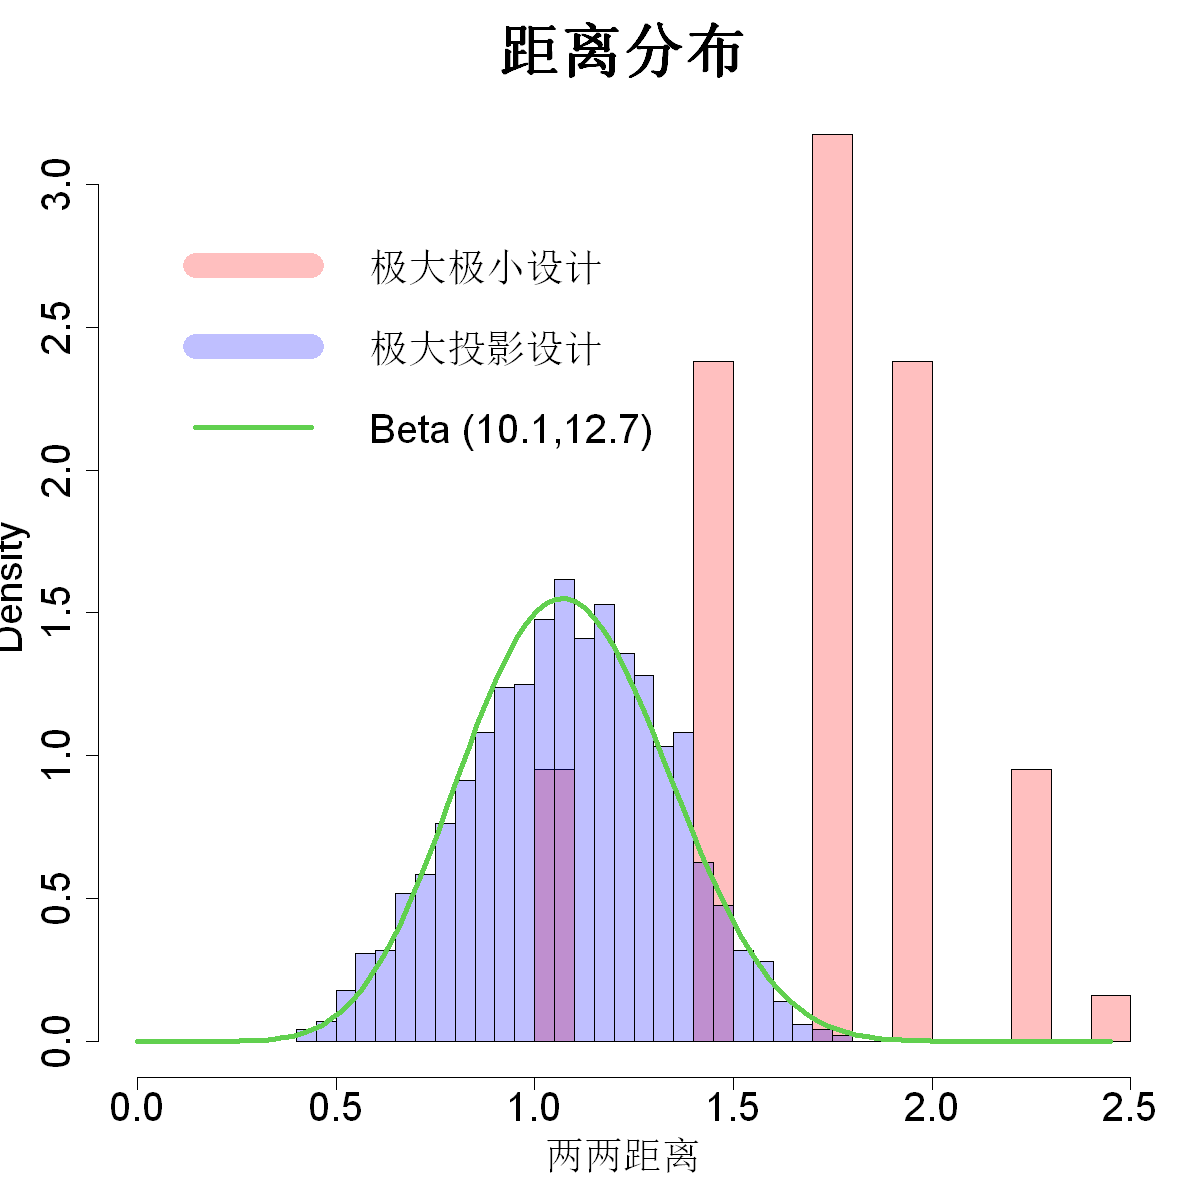

In [1]:
if(!dir.exists("data"))dir.create("data")
if(!file.exists("data/4.13-D.csv")||!file.exists("data/4.13-para.csv")){
p=6;n=64
set.seed(1)
library(SFDesign)
D1=maximin.optim(maximinLHD(n,p)$design,find.best.ini=TRUE)$design
D2=maxpro.optim(maxproLHD(n,p)$design)$design
d1=c(dist(D1)) # 2016x1
d2=c(dist(D2)) # 2016x1
library(fitdistrplus)
a=fitdist(d2/sqrt(p),"beta")
write.csv(data.frame(d1=d1,d2=d2),file="data/4.13-D.csv",row.names=FALSE)
write.csv(data.frame(shape1=a$estimate[1],shape2=a$estimate[2],p=p),file="data/4.13-para.csv",row.names=FALSE)
}

df_D=read.csv("data/4.13-D.csv")
d1=df_D$d1;d2=df_D$d2
df_para=read.csv("data/4.13-para.csv")
shape1=df_para$shape1;shape2=df_para$shape2;p=df_para$p

cat("shape1:",shape1,"\n")
cat("shape2:",shape2,"\n")

options(repr.plot.width=10,repr.plot.height=10)
hist(d1,prob=TRUE,xlim=c(0,sqrt(p)),col=adjustcolor("red",0.25),xlab="两两距离",main="距离分布",cex.lab=2,cex.axis=2,cex.main=3)
hist(d2,prob=TRUE,col=rgb(0,0,1,1/4),breaks=30,add=TRUE)
curve(dbeta(x/sqrt(p),shape1,shape2)/sqrt(p),from=0,to=sqrt(p),add=TRUE,col=3,lwd=4)
legend(0,3,legend=c("极大极小设计","极大投影设计",paste0("Beta (",round(shape1,1),",",round(shape2,1),")")),col=c(adjustcolor("red",0.25),adjustcolor("blue",0.25),3),lwd=c(20,20,4),bty="n",cex=2)

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$